# House Price Prediction

## Day 1 : Data Loading and initial exploration


## Importing required libraries

#### we import pandas for data handling and matplotlib for data visualisation

In [2]:
# import pandas 
import pandas as pd

# import matplotlib
import matplotlib.pyplot as plt

## Loading the dataset

#### we load dataset using pandas to examine its structure and contents

In [3]:
# load datset
df = pd.read_csv("data.csv")

# display first 5 rows
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## Dataset information

#### we check the structures of the dataset, including column names, data types, and missing values

In [4]:
# display dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

## Statistical summary

#### we use describe() to undersatand the distribution of numerical features

In [5]:
# statistics
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## Handling invalid values

#### we found 49 enteries where the price was 0 , which is not realistic for house prices

#### these values were treated as invalid data and removed to improve the quality of the dataset

In [6]:
(df["price"] == 0).sum()
# there are 49 values where price is 0

np.int64(49)

In [7]:
# we remove these rows which have price = 0 , as the data size is large removing 49 rows is fine
df = df[df["price"] != 0]

In [8]:
# verify removal
(df["price"] == 0).sum()

np.int64(0)

## Data visualisation

#### we plot a histogram of the target variable to understand its distribution

Text(0, 0.5, 'frequency')

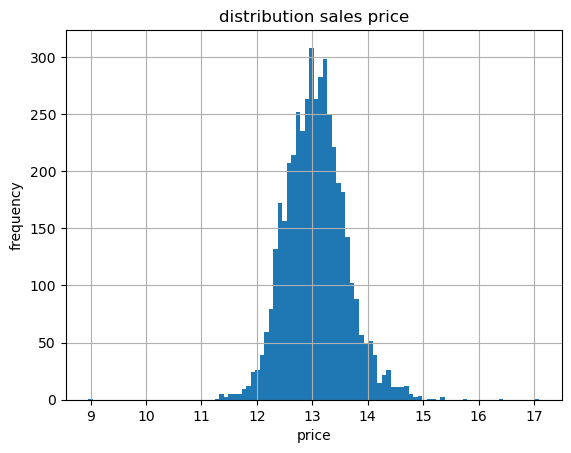

In [9]:
import numpy as np
np.log(df["price"]).hist(bins=100)

plt.title("distribution sales price")
plt.xlabel("price")
plt.ylabel("frequency")

## Observations

### Exploration

 - Dataset contains 4600 rows and 18 columns , with target varibale : price
 - found 49 enteries where price = 0 
 - the original price distribution was highly skewed to the right , with a few very high values.
   After applying log transformatiion, the distribution became more symmetric and closer to a normal distribution.
   This transformation will help improve model performance.

## Day 2 : EDA, Data preprocessing and feature engineering

## EDA

<Axes: xlabel='bedrooms', ylabel='Count'>

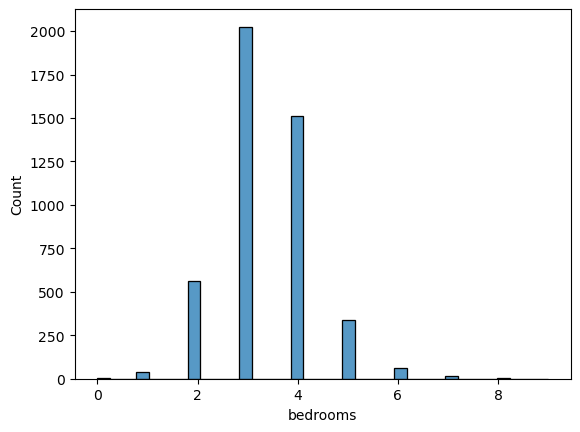

In [10]:
# feature distribution 

# important features :- bedrooms,bathrooms,sqft_living
import seaborn as sns
sns.histplot(
    data = df,
    x = "bedrooms",
    bins = 35
)

<Axes: xlabel='bathrooms', ylabel='Count'>

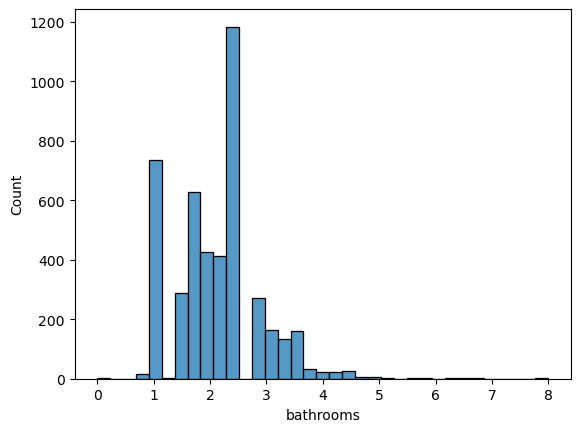

In [11]:
sns.histplot(
    data = df,
    x = "bathrooms",
    bins = 35
)

<Axes: xlabel='price'>

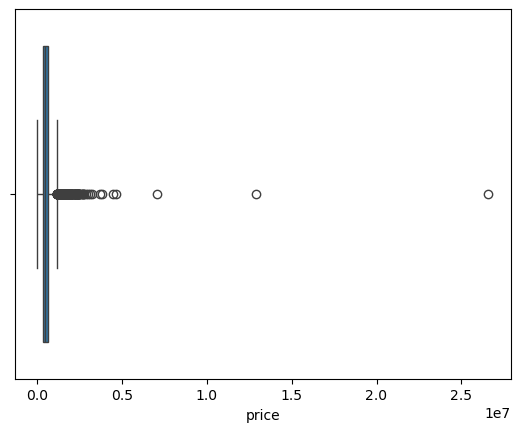

In [12]:
# outlier detection

sns.boxplot(
    data = df,
    x = "price"
)

# price is right skewed with outliers

<Axes: >

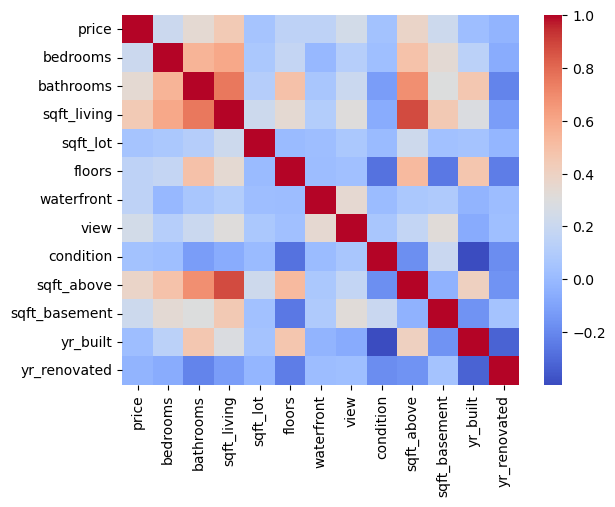

In [13]:
# correlation analysis - which feature strongly affect price

df_numeric = df.select_dtypes(include=["int64","float64"])
sns.heatmap(df_numeric.corr(),cmap="coolwarm")
# "sqft_living" shows strongly +ve correlation

<Axes: xlabel='sqft_living', ylabel='Count'>

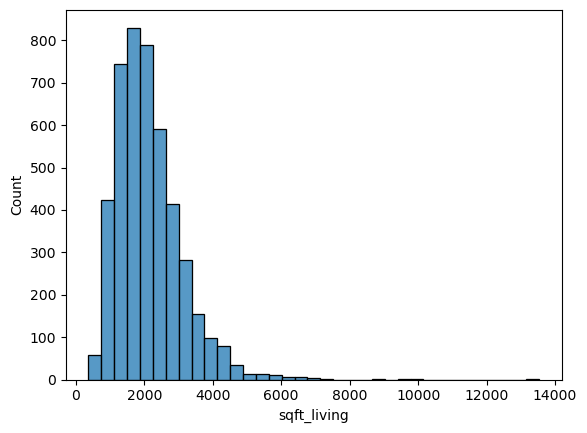

In [14]:
sns.histplot(
    data = df,
    x = "sqft_living",
    bins = 35
)

<Axes: xlabel='sqft_living', ylabel='Count'>

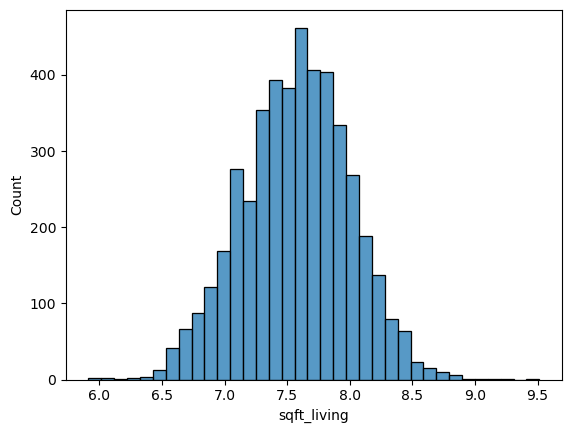

In [15]:
# the data is right-skewed , meaning that the number of houses with very large sqft_living are very less
# we do log transformation to make the data more normally distributed
df["sqft_living"] = np.log(df["sqft_living"])

sns.histplot(
    data = df,
    x = "sqft_living",
    bins = 35
)

In [16]:
# categorical analysis 

df["city"].value_counts()

city
Seattle                1561
Renton                  291
Bellevue                281
Redmond                 235
Kirkland                187
Issaquah                186
Kent                    184
Auburn                  175
Sammamish               171
Federal Way             145
Shoreline               123
Woodinville             114
Maple Valley             95
Mercer Island            82
Burien                   72
Snoqualmie               69
Kenmore                  65
Des Moines               58
North Bend               50
Duvall                   42
Covington                42
Lake Forest Park         34
Bothell                  33
Newcastle                33
Tukwila                  29
Vashon                   29
SeaTac                   28
Enumclaw                 27
Carnation                22
Normandy Park            17
Fall City                11
Medina                   11
Clyde Hill                9
Black Diamond             8
Ravensdale                7
Pacific        

<Axes: xlabel='city'>

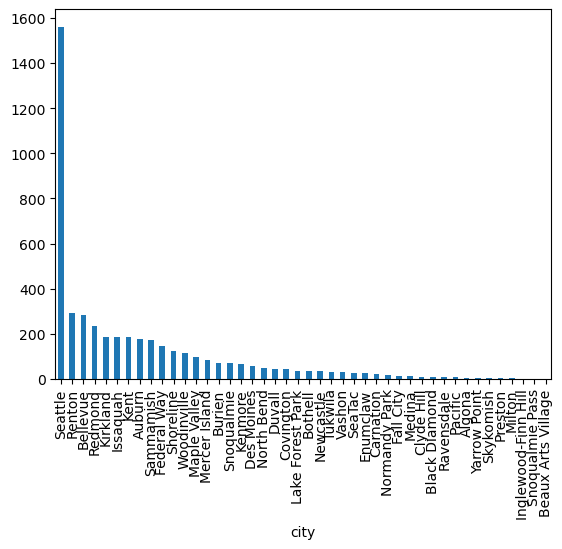

In [17]:
df["city"].value_counts().plot(kind="bar")
# most houses are from seattle, the data is not evenly distributed , so the model might not predict well for other minority cities


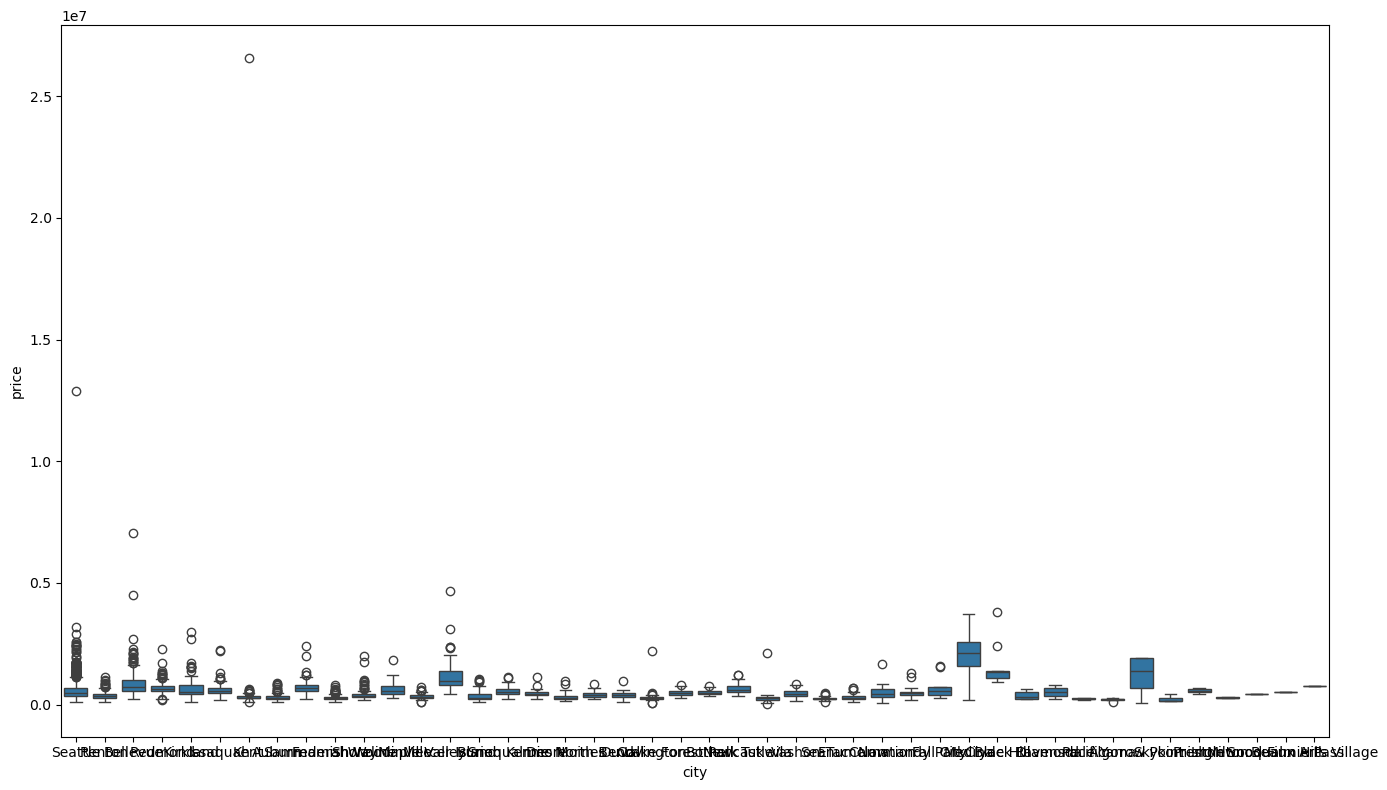

In [18]:
# compare price distributions by city

city_order = df["city"].value_counts().index
plt.figure(figsize=(14,8))
sns.boxplot(
    data = df,
    x = "city",
    y = "price",
    order = city_order
)

plt.tight_layout()
plt.show()

## Data Preprocessing 

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4551 non-null   object 
 1   price          4551 non-null   float64
 2   bedrooms       4551 non-null   float64
 3   bathrooms      4551 non-null   float64
 4   sqft_living    4551 non-null   float64
 5   sqft_lot       4551 non-null   int64  
 6   floors         4551 non-null   float64
 7   waterfront     4551 non-null   int64  
 8   view           4551 non-null   int64  
 9   condition      4551 non-null   int64  
 10  sqft_above     4551 non-null   int64  
 11  sqft_basement  4551 non-null   int64  
 12  yr_built       4551 non-null   int64  
 13  yr_renovated   4551 non-null   int64  
 14  street         4551 non-null   object 
 15  city           4551 non-null   object 
 16  statezip       4551 non-null   object 
 17  country        4551 non-null   object 
dtypes: float64(5)

In [20]:
# handle missing values 

df.isnull().sum()

# no missing values

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

<Axes: xlabel='price', ylabel='Count'>

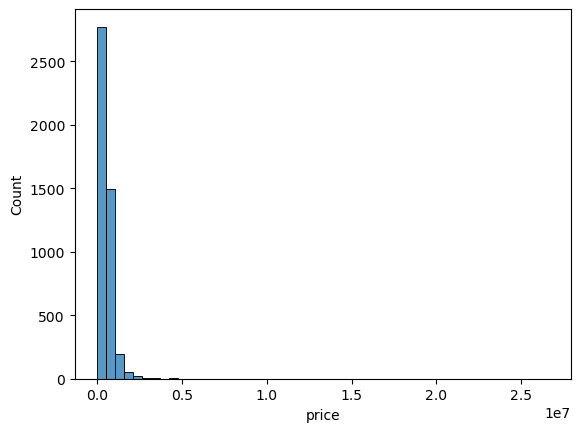

In [21]:
# handle skewed target

sns.histplot(
    data = df,
    x = "price",
    bins = 50
)

# target "price" is highly right skewed 

<Axes: xlabel='log_price', ylabel='Count'>

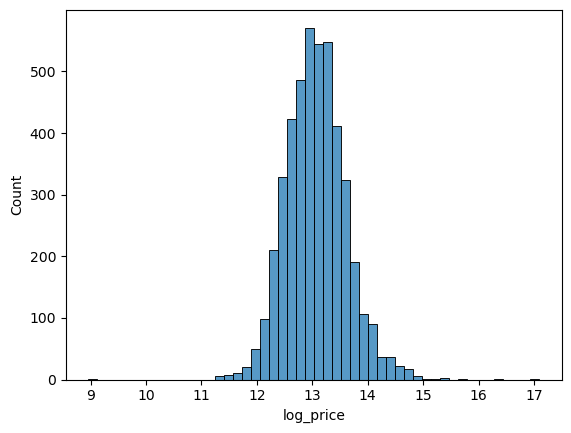

In [22]:
df["log_price"] = np.log1p(df["price"])
sns.histplot(
    data = df,
    x = "log_price",
    bins = 50
)


<Axes: xlabel='log_price'>

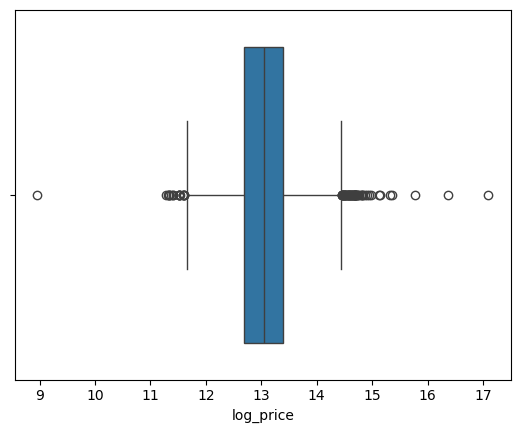

In [23]:
# remove outliers
# since we converted the price to logPrice so the outliers becomes less extreme , np need to remove them 

sns.boxplot(
    data = df,
    x = "log_price"
)

In [76]:
"""
the model :
. trains on log(price)
. predicts log(price)
Then you manually convert predictions back to original price
"""

'\nthe model :\n. trains on log(price)\n. predicts log(price)\nThen you manually convert predictions back to original price\n'

In [24]:
# encoding categorical columns 

df = pd.get_dummies(df,columns=["city"],drop_first=True)

## Feature engineering 



In [25]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,2014-05-02 00:00:00,313000.0,3.0,1.50,7.200425,7912,1.5,0,0,3,...,False,False,True,False,False,False,False,False,False,False
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,8.202482,9050,2.0,0,4,5,...,False,True,False,False,False,False,False,False,False,False
2,2014-05-02 00:00:00,342000.0,3.0,2.00,7.565275,11947,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False
3,2014-05-02 00:00:00,420000.0,3.0,2.25,7.600902,8030,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False
4,2014-05-02 00:00:00,550000.0,4.0,2.50,7.570443,10500,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False


In [26]:
# making new features 

df["price_per_sqft"] = df["price"]/df["sqft_living"]

df["year"] = pd.to_datetime(df["date"]) # since values in "date" column was string , we first have to convert it to datetime datatype
df["year"] = pd.to_datetime(df["date"]).dt.year 

df["house_age"] = df["year"] - df["yr_built"]

df["sqft_per_bedroom"] = df["sqft_living"] / (df["bedrooms"]+1)

df["total_rooms"] = df["bedrooms"]+ (df["bathrooms"]+1)

df["sqft_per_floor"] = df["sqft_living"]/df["floors"]

df["bath_per_bedroom"] = df["bathrooms"]/(df["bedrooms"]+1) # +1 as if number of bedrooms is zero then dividing by 0 is not ok

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 68 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      4551 non-null   object 
 1   price                     4551 non-null   float64
 2   bedrooms                  4551 non-null   float64
 3   bathrooms                 4551 non-null   float64
 4   sqft_living               4551 non-null   float64
 5   sqft_lot                  4551 non-null   int64  
 6   floors                    4551 non-null   float64
 7   waterfront                4551 non-null   int64  
 8   view                      4551 non-null   int64  
 9   condition                 4551 non-null   int64  
 10  sqft_above                4551 non-null   int64  
 11  sqft_basement             4551 non-null   int64  
 12  yr_built                  4551 non-null   int64  
 13  yr_renovated              4551 non-null   int64  
 14  street       

<Axes: >

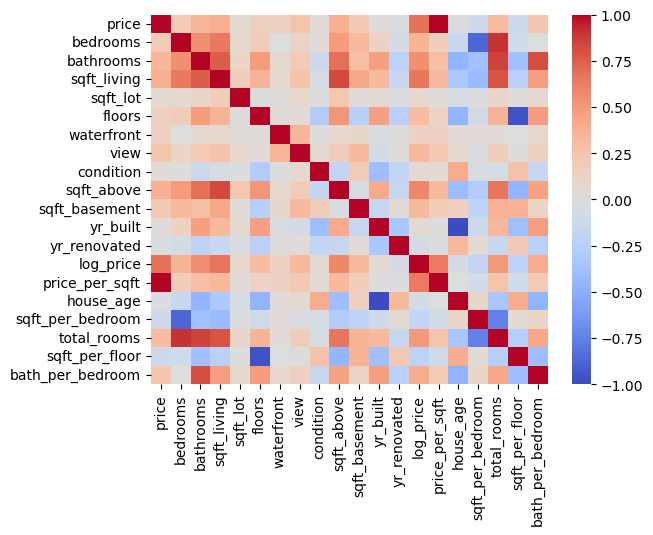

In [28]:
# to check features which are highly correlated, to remove any original features after making new features

df_numeric = df.select_dtypes(include=["int64","float64"])
sns.heatmap(df_numeric.corr(),cmap="coolwarm")



## Obseravtions 

### Exploration 

    EDA: 
    
. from boxplot for target(price) , I detected outliers

.from histplot for taget(price) , I analyzed that the "price" was right skewed

. also the feature "sqft_living" is right skewed 

. using the correlation heatmap , I analyzed that the feature "sqft_living" is highly correlated to the target 

.for the "city" the data is not evenly distributed , with mostly cities being seattle  
    
    Data Preprocessing:
    
. I converted the "price" to "log_price" to handle the skewness and the outliers 

. also handled the skewness for "sqft_living" by changing it into log

. I did OneHotEncode for the "city" 

    Feature Engineering:

.I made new impactful features such as "price_per_sqft","house_age","total_rooms","sqft_per_floor","sqft_per_bedroom"


# Day 3 : Model training , Evaluation

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
df["country"].value_counts() # since there are no variation in the countries , the model learns nothing from this feature so we can remove this feature

country
USA    4551
Name: count, dtype: int64

In [31]:
X = df.drop(columns = ["price","street","statezip","date","country","log_price"],axis=1)
y = df["log_price"]

In [32]:
# train test split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [33]:
# feature scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
# linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [35]:
y_pred = model.predict(X_test_scaled)

In [36]:
# convert predictions back to original price from log_price

y_pred_actual = np.expm1(y_pred)

# also convert y_test 

y_test_actual = np.expm1(y_test)

In [39]:
# Evaluation 

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_score = r2_score(y_test_actual,y_pred_actual) # how well does the model explain the data
print("r2_score is : ",r2_score)

mean_squared_error = mean_squared_error(y_test_actual,y_pred_actual) # good when large errors are unacceptable
print("mse is : ",mean_squared_error)

rmse = np.sqrt(mean_squared_error) # on average , by how much are my predictions wrong , same unit as target 
print("rmse is : ",rmse) # on average , predictions are off by $150K

mean_absolute_error = mean_absolute_error(y_test_actual,y_pred_actual) # for stable evaluation , data has outliers
print("mae is : ",mean_absolute_error)

r2_score is :  0.8151936989801762
mse is :  23865658868.333015
rmse is :  154485.14125420936
mae is :  87125.03648154695


## Observations 

### Exploration

. I droped both the "log_price" and "price" from the X

. for the taget feature I used "log_price" instead of "price"

. after the train_test_split I did feature scaling to improve my model performance especially since I am using Linear            Regression model 

. after the model is trained , I predicted the target values which are in log_price so we need to convert it back to the         original price , so I converted both the y_pred and y_test to the original values 

. for evaluating the performance of the model I used different evaluation metrics such as r2_score,mean_squared_error,rmse       ,mean_absolute_error

### Model Performance

. A linear Regression model was trained on scaled features.

  The model achieved:
    . r2_score = 0.81 -> explaining ~81% of variance
    . RMSE = 150,000 -> average prediction error

  The model performs reasonably well but still has notable prediction errors due to the complexity of the housing data.

### Challenges faced 

. initially, using log(price) caused issue due to zero values , leading to infinite values and unstable predictions . 
  this was resolved using log1p
. proper steps like scaling after train_test_split were crucial to avoid data leakage 